In [ ]:

# TITANIC DATASET
!pip install -q imbalanced-learn statsmodels joblib

# Imports sk.learn libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.feature_selection import mutual_info_classif

from imblearn.over_sampling import SMOTE

import statsmodels.api as sm

import joblib

# Display settings
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

# TASK 1 — LOAD DATA

# Load Titanic dataset
df_original = sns.load_dataset("titanic")

print("First 5 rows:")
display(df_original.head())

print("\nINFO:")
print(df_original.info())

print("\nDESCRIBE:")
display(df_original.describe(include="all"))

print("\nSHAPE:")
print(df_original.shape)
# Missing percentage before any cleaning
missing_percentage = (
    df_original.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nMissing percentage by column:")
display(missing_percentage.to_frame("Missing_Percentage"))

df_original.to_csv("titanic.csv", index=False)

print("\nBaseline saved as titanic.csv")


# Reload the same CSV

df = pd.read_csv("titanic.csv")

print("\nReloaded titanic.csv")
print(df.shape)

display(df.head())

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

DESCRIBE:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



SHAPE:
(891, 15)

Missing percentage by column:


,Missing_Percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000



Baseline saved as titanic.csv

Reloaded titanic.csv
(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:

# TASK 2 — MISSING VALUE HANDLING

print("Missing values BEFORE cleaning:")
display(df.isnull().sum())

missing_pct = df.isnull().mean() * 100

print("\nMissing percentage:")
display(missing_pct.sort_values(ascending=False))

# Columns with >30% missing
drop_columns = missing_pct[missing_pct > 30].index.tolist()

# Columns with 5%-30% missing
impute_columns = missing_pct[
    (missing_pct >= 5) & (missing_pct <= 30)
].index.tolist()

# Columns with <5% missing
drop_row_columns = missing_pct[
    (missing_pct > 0) & (missing_pct < 5)
].index.tolist()

print("\nColumns to DROP:")
print(drop_columns)

print("\nColumns to IMPUTE:")
print(impute_columns)

print("\nColumns where ROWS will be dropped:")
print(drop_row_columns)


# Drop columns having >30% missing


df = df.drop(columns=drop_columns)


# Drop rows for columns with <5% missing


if len(drop_row_columns) > 0:
    df = df.dropna(subset=drop_row_columns)


# Impute 5%-30% missing values
# Numeric -> median
# Categorical -> mode


for col in impute_columns:

    if col not in df.columns:
        continue

    if pd.api.types.is_numeric_dtype(df[col]):

        df[col] = df[col].fillna(df[col].median())

    else:

        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values AFTER cleaning:")
display(df.isnull().sum())

print("\nShape after cleaning:")
print(df.shape)





print("""
MISSING-VALUE STRATEGY:

1. Columns with less than 5% missing values:
   Rows containing these missing values were removed because
   the amount of data lost is very small.

2. Columns with 5%-30% missing values:
   Missing values were imputed because removing these rows
   would unnecessarily reduce the dataset size.

3. Columns with more than 30% missing values:
   The column was removed because too much information was missing
   and reliable imputation would be difficult.
""")

Missing values BEFORE cleaning:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0



Missing percentage:


,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000



Columns to DROP:
['deck']

Columns to IMPUTE:
['age']

Columns where ROWS will be dropped:
['embarked', 'embark_town']

Missing values AFTER cleaning:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0



Shape after cleaning:
(889, 14)

MISSING-VALUE STRATEGY:

1. Columns with less than 5% missing values:
   Rows containing these missing values were removed because
   the amount of data lost is very small.

2. Columns with 5%-30% missing values:
   Missing values were imputed because removing these rows
   would unnecessarily reduce the dataset size.

3. Columns with more than 30% missing values:
   The column was removed because too much information was missing
   and reliable imputation would be difficult.



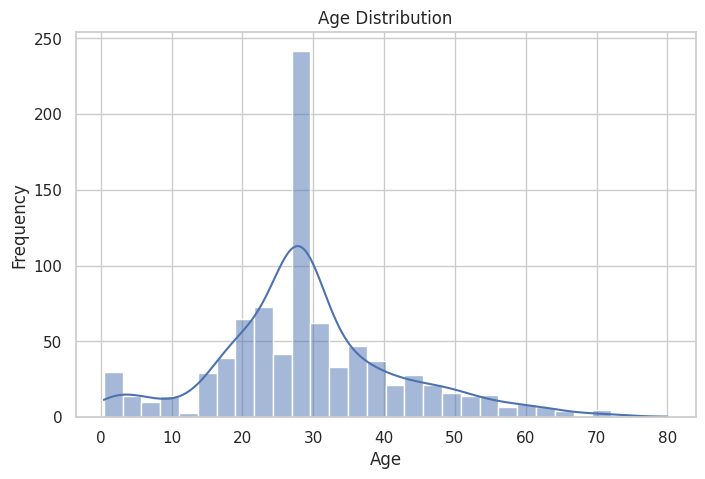

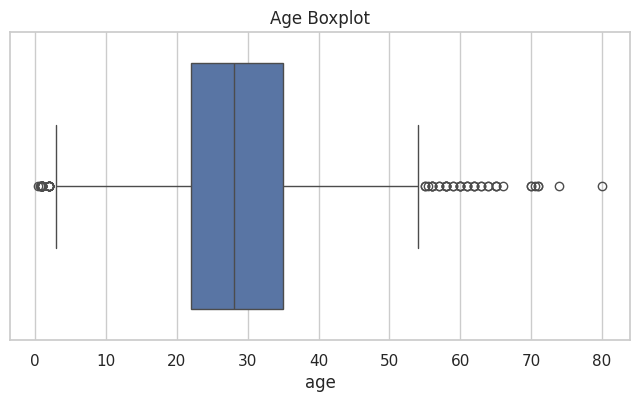

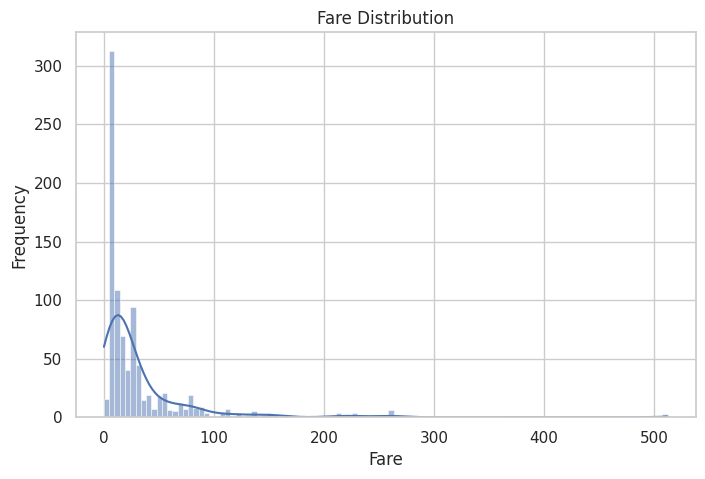

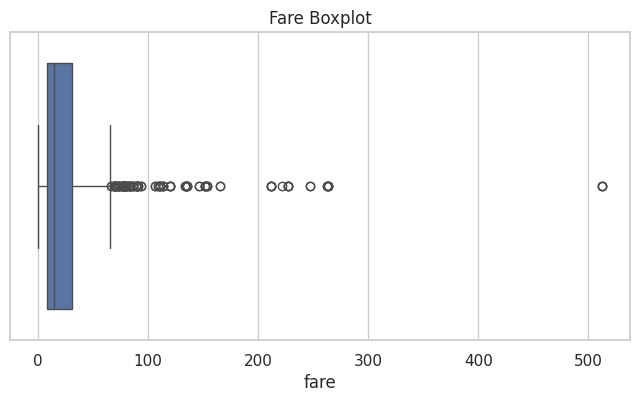

AGE
Number of IQR outliers: 65
Lower bound: 2.5
Upper bound: 54.5

FARE
Number of IQR outliers: 114
Lower bound: -26.7605
Upper bound: 65.6563

Age skewness: 0.5080100783148638
Fare skewness: 4.801440211044194
Fare is right-skewed / positively skewed.


In [ ]:

# TASK 3 — UNIVARIATE ANALYSIS
# AGE HISTOGRAM
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
# AGE BOXPLOT
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.show()
# FARE HISTOGRAM
plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()
# FARE BOXPLOT
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare"])
plt.title("Fare Boxplot")
plt.show()



# IQR OUTLIER FUNCTION


def iqr_outlier_count(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound
# Age
age_outliers, age_lower, age_upper = iqr_outlier_count(df["age"])

# Fare
fare_outliers, fare_lower, fare_upper = iqr_outlier_count(df["fare"])

print("AGE")
print("Number of IQR outliers:", age_outliers)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)

print("\nFARE")
print("Number of IQR outliers:", fare_outliers)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)

# SKEWNESS

age_skew = df["age"].skew()
fare_skew = df["fare"].skew()

print("\nAge skewness:", age_skew)
print("Fare skewness:", fare_skew)

if abs(fare_skew) < 0.5:
    print("Fare is approximately symmetric.")

elif fare_skew > 0:
    print("Fare is right-skewed / positively skewed.")

else:
    print("Fare is left-skewed / negatively skewed.")

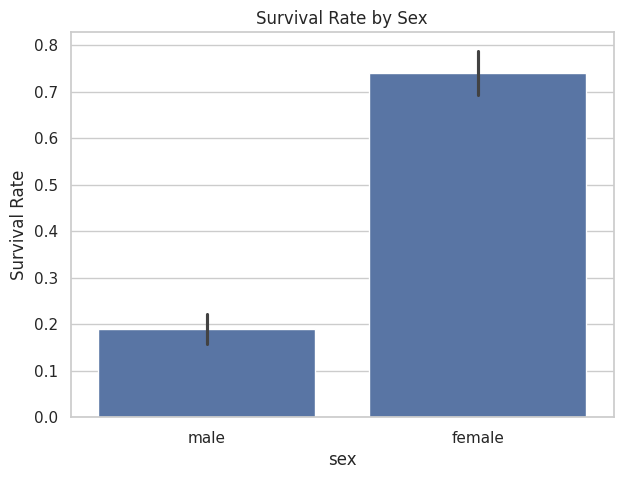

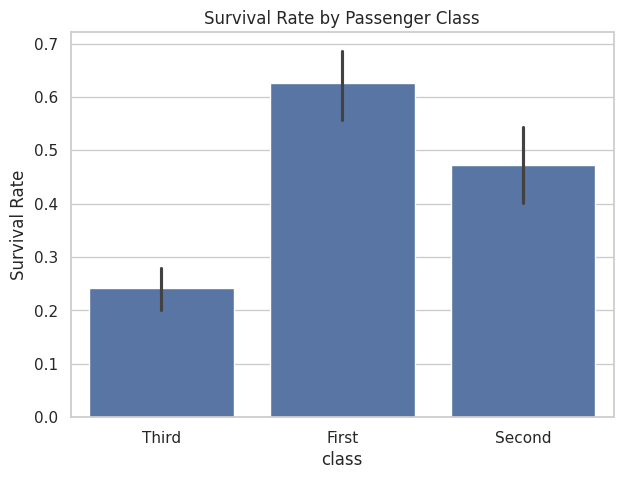

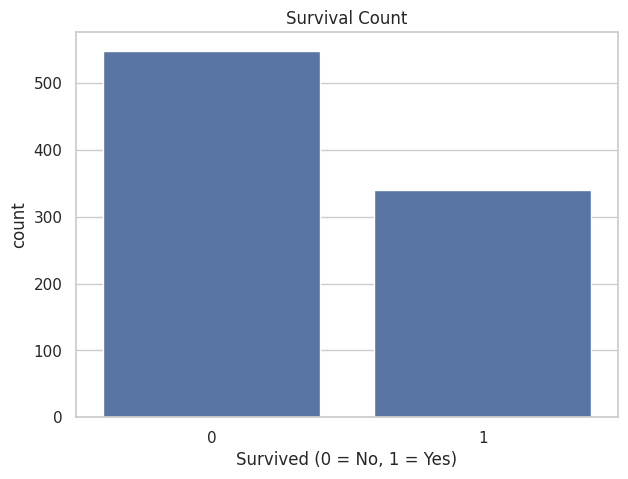

Survival rate by sex:


,survived
sex,
female,0.740385
male,0.188908



Survival rate by class:


,survived
class,
First,0.626168
Second,0.472826
Third,0.242363


In [ ]:

# TASK 4 — BIVARIATE ANALYSIS

# Survival by Sex

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

# Survival by Class

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="class",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

# Survival count

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="survived"
)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.show()

# Exact survival rates
print("Survival rate by sex:")
display(
    df.groupby("sex")["survived"]
      .mean()
      .sort_values(ascending=False)
)

print("\nSurvival rate by class:")
display(
    df.groupby("class")["survived"]
      .mean()
      .sort_values(ascending=False)
)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


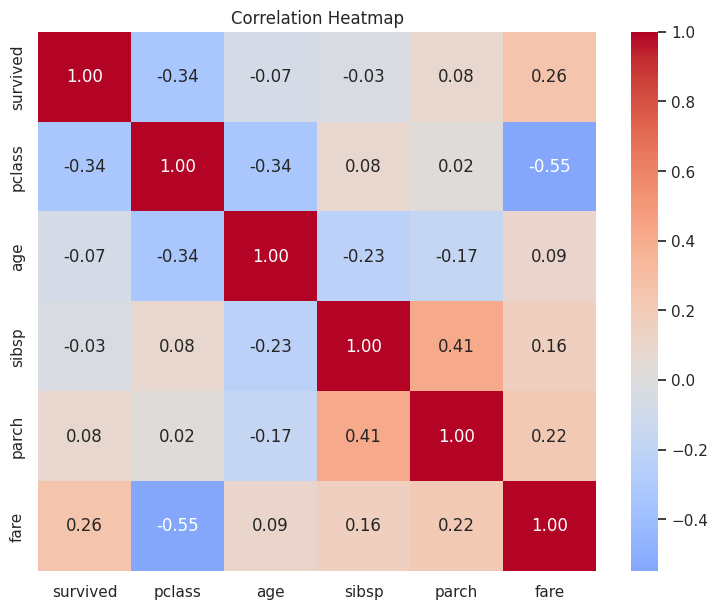


Two strongest correlations:


,Feature_1,Feature_2,Correlation,Absolute_Correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


In [ ]:
# TASK 5 — CORRELATION ANALYSIS
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_columns].corr()

print("Correlation Matrix:")
display(corr_matrix)
# Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# FIND TWO STRONGEST OFF-DIAGONAL CORRELATIONS

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

corr_pairs["Absolute_Correlation"] = (
    corr_pairs["Correlation"].abs()
)

top_two = corr_pairs.sort_values(
    "Absolute_Correlation",
    ascending=False
).head(2)

print("\nTwo strongest correlations:")
display(top_two)

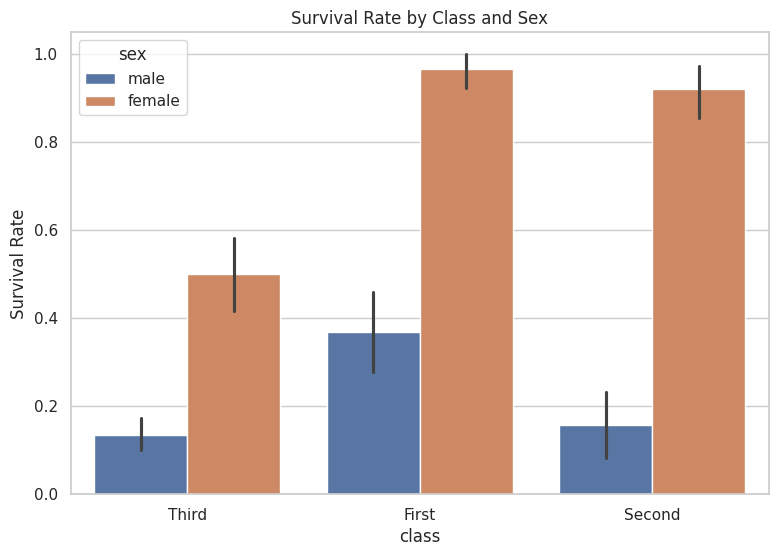

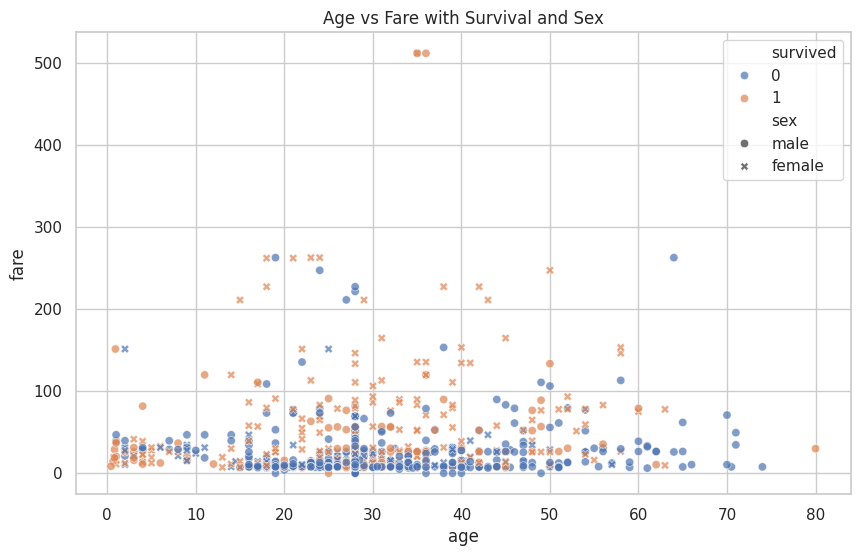

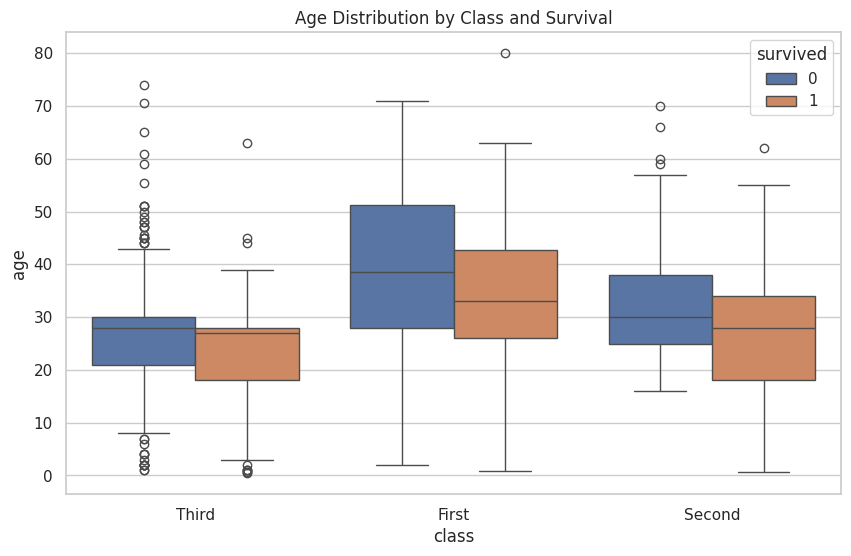

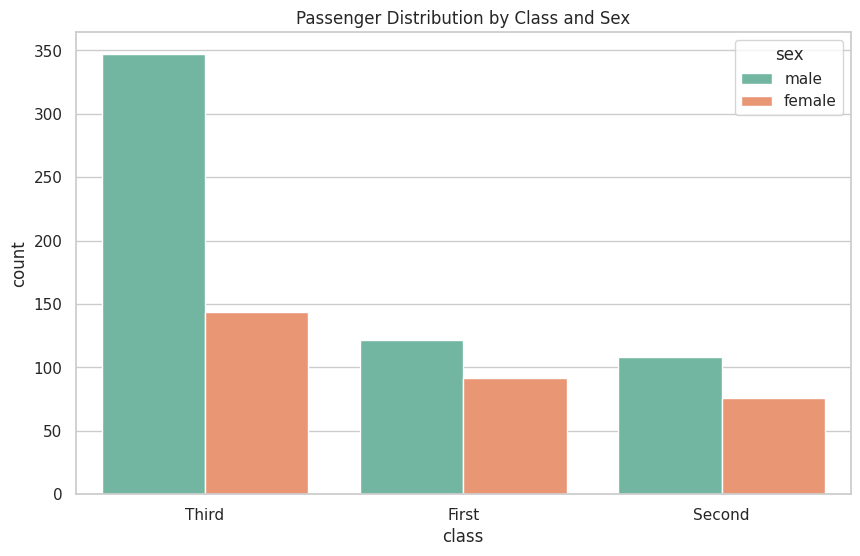

In [ ]:

# MULTIVARIATE CHART 1

plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="class",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Class and Sex")
plt.ylabel("Survival Rate")
plt.show()

# MULTIVARIATE CHART 2

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age vs Fare with Survival and Sex")
plt.show()

# MULTIVARIATE CHART 3

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="class",
    y="age",
    hue="survived"
)

plt.title("Age Distribution by Class and Survival")
plt.show()

# MULTIVARIATE CHART 4

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="class",
    hue="sex",
    palette="Set2"
)

plt.title("Passenger Distribution by Class and Sex")
plt.show()

BEFORE STANDARDIZATION
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

AFTER STANDARDIZATION
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


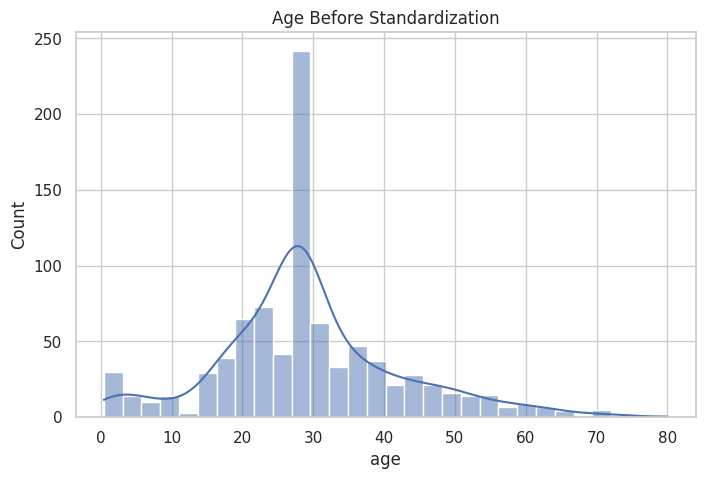

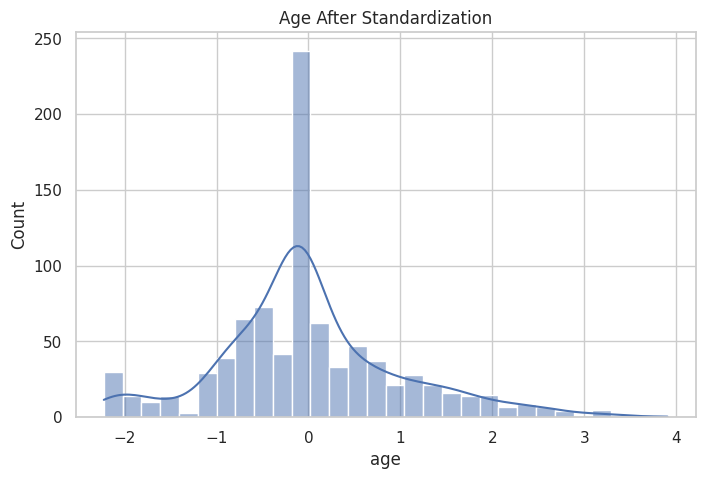

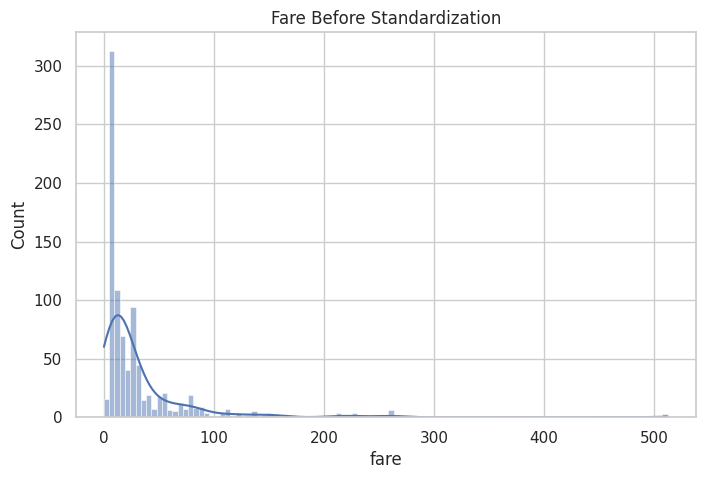

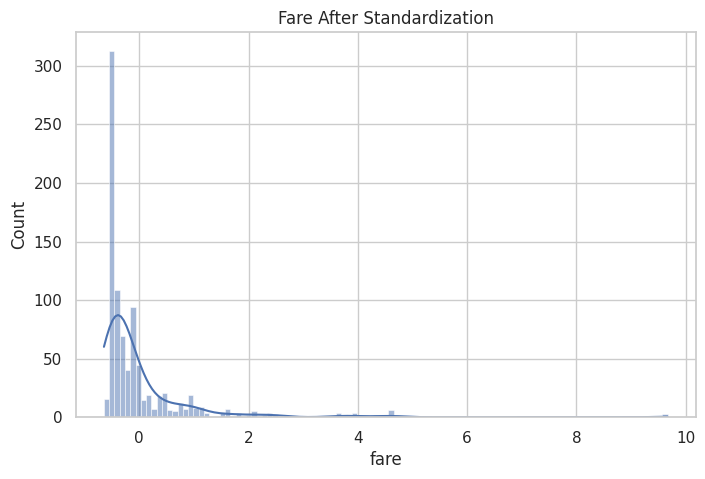

In [ ]:
# TASK 6 — STANDARDIZATION CHECK

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[
    ["age", "fare"]
] = scaler.fit_transform(
    df[["age", "fare"]]
)

# BEFORE

print("BEFORE STANDARDIZATION")

print(
    df[["age", "fare"]]
    .agg(["mean", "std"])
)

# AFTER

print("\nAFTER STANDARDIZATION")

print(
    df_standardized[["age", "fare"]]
    .agg(["mean", "std"])
)

# Visual comparison — AGE

plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    kde=True
)

plt.title("Age Before Standardization")
plt.show()


plt.figure(figsize=(8, 5))

sns.histplot(
    df_standardized["age"],
    kde=True
)

plt.title("Age After Standardization")
plt.show()

# Visual comparison — FARE

plt.figure(figsize=(8, 5))

sns.histplot(
    df["fare"],
    kde=True
)

plt.title("Fare Before Standardization")
plt.show()


plt.figure(figsize=(8, 5))

sns.histplot(
    df_standardized["fare"],
    kde=True
)

plt.title("Fare After Standardization")
plt.show()

In [ ]:
# TASK 7 — TRAIN / TEST SPLIT

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True) * 100
)

print("\nTest target distribution:")
print(y_test.value_counts())

X_train: (711, 13)
X_test : (178, 13)

Training target distribution:
survived
0    439
1    272
Name: count, dtype: int64

Training target percentage:
survived
0    61.744023
1    38.255977
Name: proportion, dtype: float64

Test target distribution:
survived
0    110
1     68
Name: count, dtype: int64


In [ ]:
# ============================================================
# TASK 8 — PREPROCESSING
# ============================================================

# Identify numeric and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ------------------------------------------------------------
# Numeric pipeline
# ------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# Categorical pipeline
# ------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# Combined preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
Preprocessor created.


In [ ]:
# ============================================================
# TASK 9 — THREE CLASSIFIERS
# ============================================================

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# Train models
# ------------------------------------------------------------

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

for name, model in models.items():

    model.fit(X_train, y_train)

    print(name, "trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


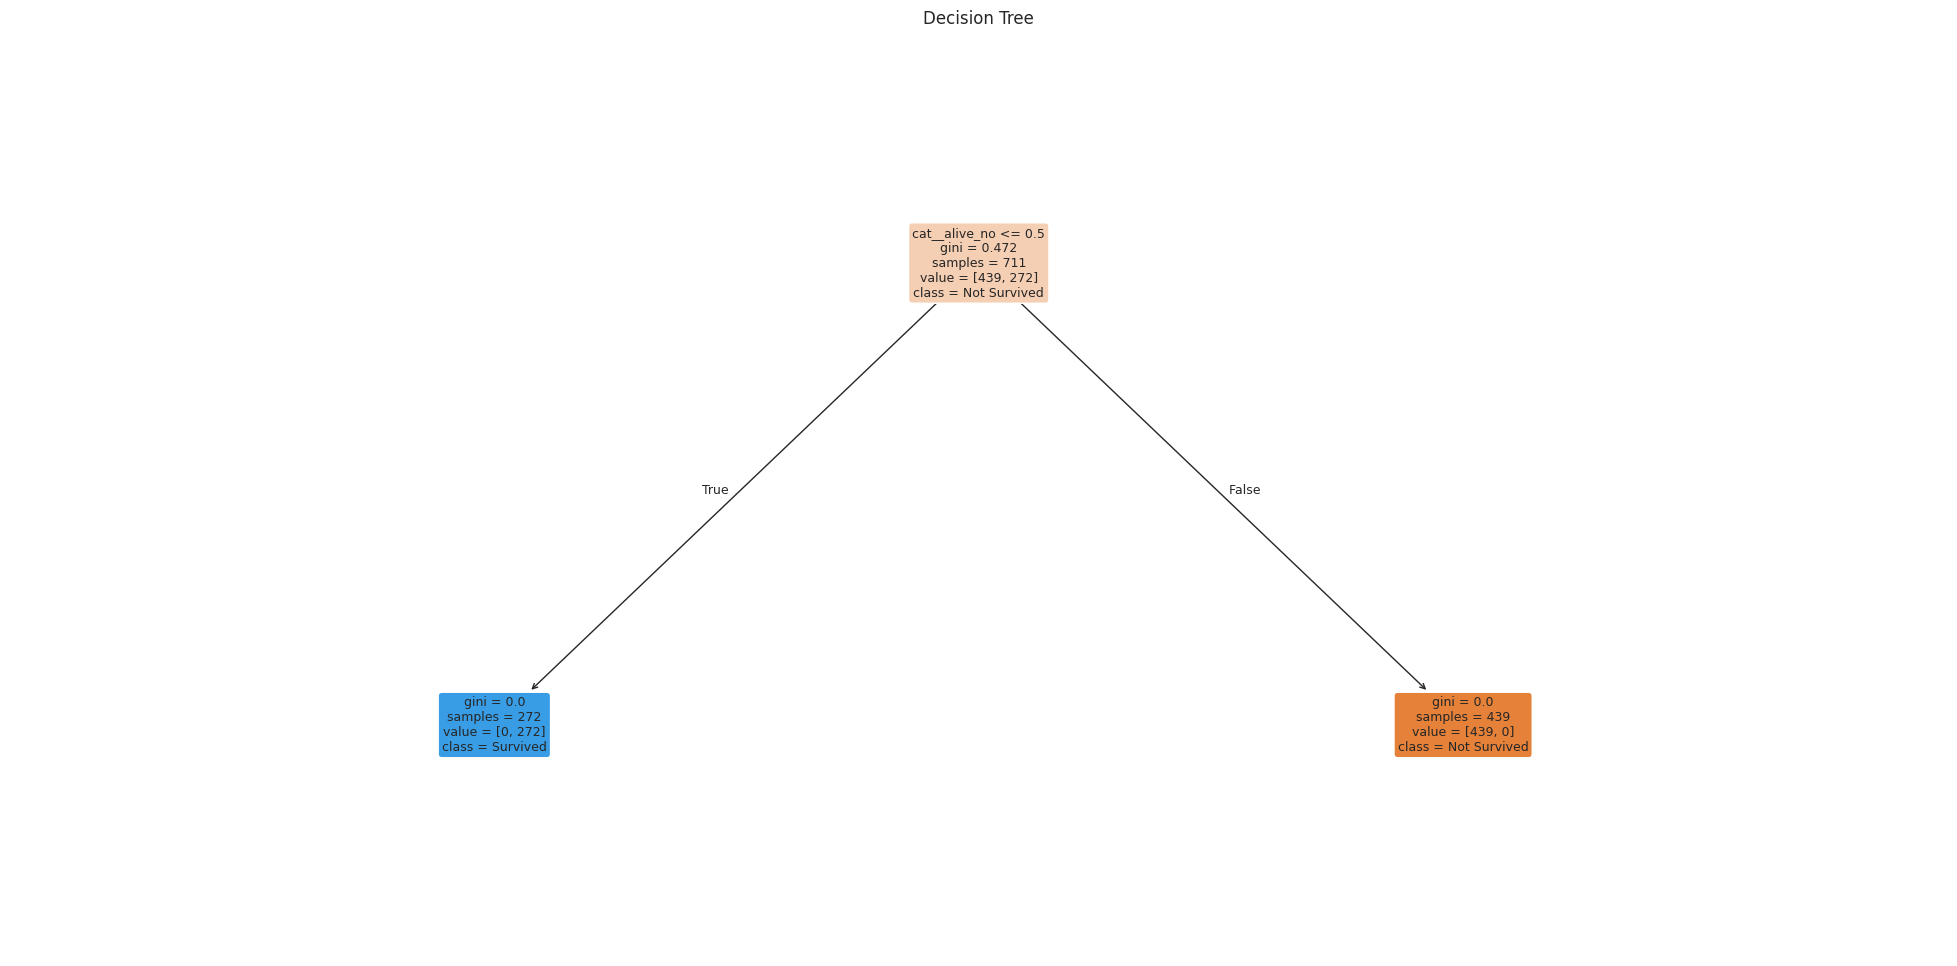

In [ ]:
# ============================================================
# DECISION TREE VISUALIZATION
# ============================================================

# Get transformed feature names
feature_names = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

tree_model = (
    decision_tree_pipeline
    .named_steps["model"]
)

plt.figure(figsize=(25, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)

plt.title("Decision Tree")
plt.show()


Logistic Regression

Confusion Matrix:
[[110   0]
 [  0  68]]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


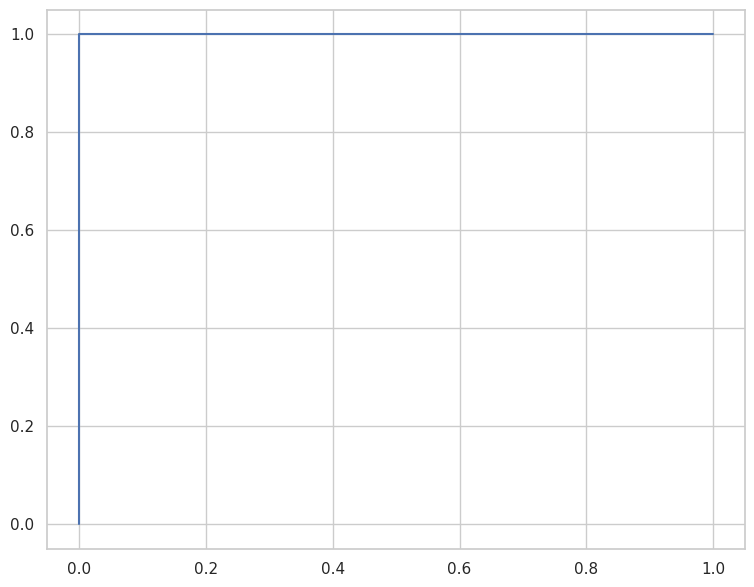

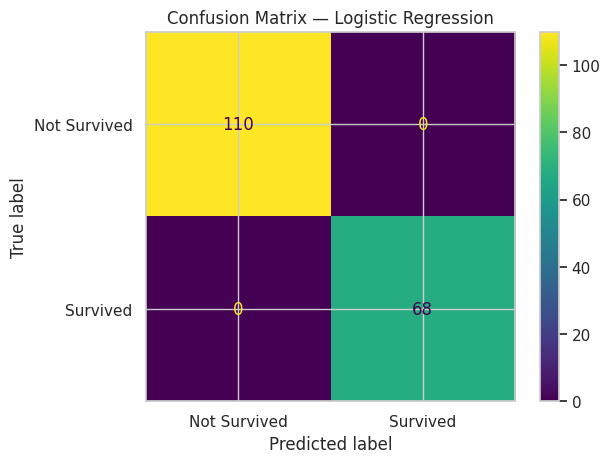


Decision Tree

Confusion Matrix:
[[110   0]
 [  0  68]]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


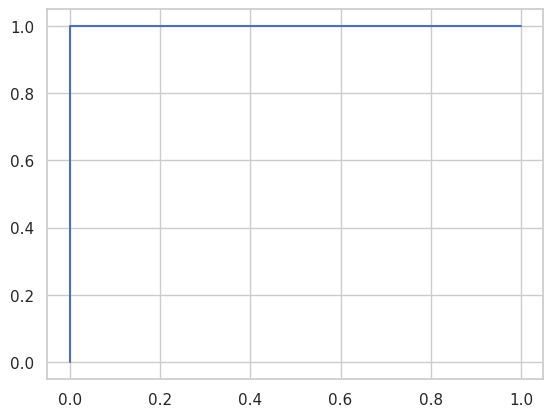

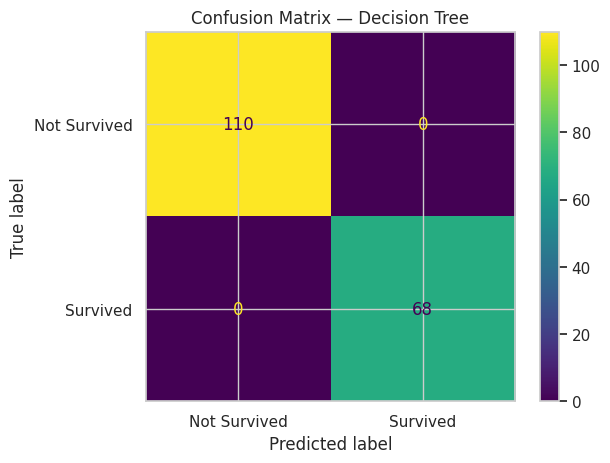


Random Forest

Confusion Matrix:
[[110   0]
 [  0  68]]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


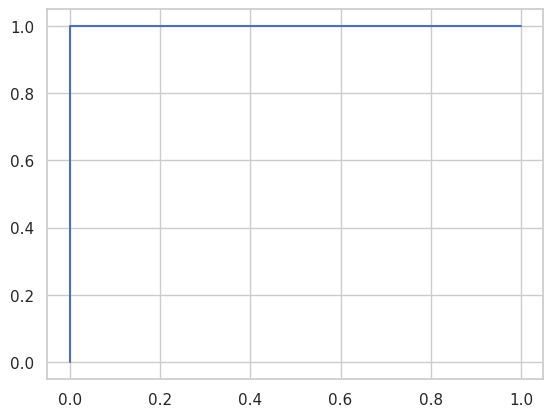

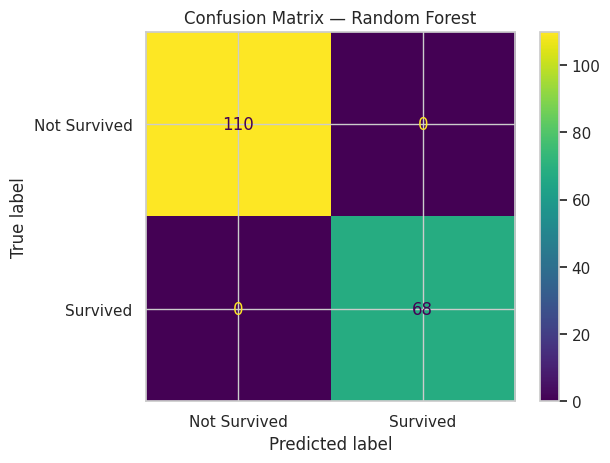

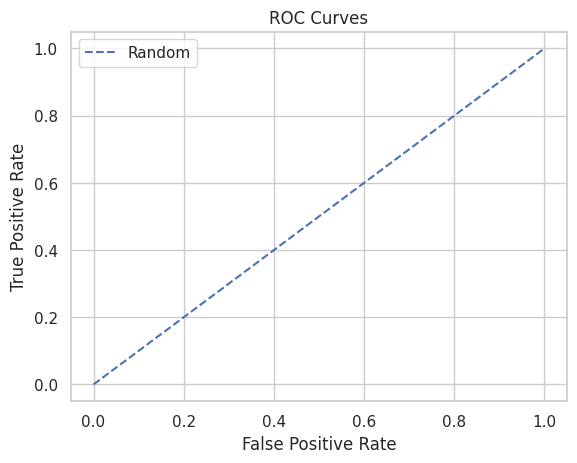


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ============================================================
# TASK 10 — MODEL EVALUATION
# ============================================================

results = []

plt.figure(figsize=(9, 7))

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc
    })

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\n====================================")
    print(name)
    print("====================================")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nAccuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))

    # --------------------------------------------------------
    # ROC curve
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

    # --------------------------------------------------------
    # Individual confusion matrix
    # --------------------------------------------------------

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


# ROC curve
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


# Results table
results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
display(
    results_df.sort_values(
        "ROC-AUC",
        ascending=False
    )
)

In [ ]:
# ============================================================
# TASK 11 — IMBALANCE HANDLING
# ============================================================

print("Original target distribution:")
display(
    y.value_counts()
)

print("\nOriginal target percentage:")
display(
    y.value_counts(normalize=True) * 100
)


# ============================================================
# VERSION 1 — BASELINE
# ============================================================

baseline_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)

baseline_metrics = {
    "Method": "Baseline",
    "Accuracy": accuracy_score(
        y_test,
        baseline_pred
    ),
    "Precision": precision_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        baseline_pred,
        zero_division=0
    )
}


# ============================================================
# VERSION 2 — CLASS WEIGHT BALANCED
# ============================================================

balanced_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_rf.fit(X_train, y_train)

balanced_pred = balanced_rf.predict(X_test)

balanced_metrics = {
    "Method": "class_weight='balanced'",
    "Accuracy": accuracy_score(
        y_test,
        balanced_pred
    ),
    "Precision": precision_score(
        y_test,
        balanced_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        balanced_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        balanced_pred,
        zero_division=0
    )
}


# ============================================================
# VERSION 3 — SMOTE
# ============================================================

# First transform data using preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

# Apply SMOTE ONLY to training data
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


# Train RF on SMOTE data
smote_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

smote_rf.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_rf.predict(
    X_test_processed
)

smote_metrics = {
    "Method": "SMOTE",
    "Accuracy": accuracy_score(
        y_test,
        smote_pred
    ),
    "Precision": precision_score(
        y_test,
        smote_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        smote_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        smote_pred,
        zero_division=0
    )
}


# ============================================================
# COMPARISON
# ============================================================

imbalance_results = pd.DataFrame([
    baseline_metrics,
    balanced_metrics,
    smote_metrics
])

print("\nIMBALANCE COMPARISON")
display(imbalance_results)

Original target distribution:


,count
survived,
0,549
1,340



Original target percentage:


,proportion
survived,
0,61.754781
1,38.245219


Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

IMBALANCE COMPARISON


,Method,Accuracy,Precision,Recall,F1
0,Baseline,1.0,1.0,1.0,1.0
1,class_weight='balanced',1.0,1.0,1.0,1.0
2,SMOTE,1.0,1.0,1.0,1.0


In [ ]:
# ============================================================
# TASK 12 — RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_for_grid = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                oob_score=True,
                bootstrap=True
            )
        )
    ]
)


# ------------------------------------------------------------
# Parameter grid
# ------------------------------------------------------------

param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}


# ------------------------------------------------------------
# Stratified CV
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# GridSearchCV
# ------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)


grid_search.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)


# ------------------------------------------------------------
# OOB Score
# ------------------------------------------------------------

best_rf_pipeline = grid_search.best_estimator_

best_rf_model = (
    best_rf_pipeline
    .named_steps["model"]
)

print("\nOOB Score:")
print(best_rf_model.oob_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best CV ROC-AUC:
1.0

OOB Score:
1.0


In [ ]:
# ============================================================
# TASK 13 — REGRESSION
# Predict FARE
# ============================================================

# ------------------------------------------------------------
# Create regression dataset
# ------------------------------------------------------------

reg_df = df.copy()

# Target
y_reg = reg_df["fare"]

# Remove target
X_reg = reg_df.drop(columns=["fare"])


# ------------------------------------------------------------
# Train-test split
# ------------------------------------------------------------

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# Identify columns
# ------------------------------------------------------------

reg_numeric = X_reg_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical = X_reg_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Regression numeric features:")
print(reg_numeric)

print("\nRegression categorical features:")
print(reg_categorical)


# ------------------------------------------------------------
# Regression preprocessing
# ------------------------------------------------------------

reg_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

reg_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_pipeline,
            reg_numeric
        ),
        (
            "cat",
            reg_categorical_pipeline,
            reg_categorical
        )
    ]
)


# ------------------------------------------------------------
# Linear Regression pipeline
# ------------------------------------------------------------

regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

y_reg_pred = regression_pipeline.predict(
    X_reg_test
)


# ============================================================
# REGRESSION METRICS
# ============================================================

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)


# ------------------------------------------------------------
# Adjusted R²
# ------------------------------------------------------------

X_reg_test_processed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

n = X_reg_test_processed.shape[0]
p = X_reg_test_processed.shape[1]

adjusted_r2 = (
    1 -
    ((1 - r2) * (n - 1)) /
    (n - p - 1)
)


print("\n==============================")
print("REGRESSION RESULTS")
print("==============================")

print("R²          :", round(r2, 4))
print("MAE         :", round(mae, 4))
print("RMSE        :", round(rmse, 4))
print("Adjusted R² :", round(adjusted_r2, 4))

Regression numeric features:
['survived', 'pclass', 'age', 'sibsp', 'parch']

Regression categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

REGRESSION RESULTS
R²          : 0.3609
MAE         : 18.3735
RMSE        : 41.2921
Adjusted R² : 0.2558


In [ ]:
# ============================================================
# HETEROSCEDASTICITY TEST
# ============================================================

# Residuals
residuals = y_reg_test - y_reg_pred

# Add constant
X_bp = sm.add_constant(
    X_reg_test_processed
)

# Breusch-Pagan test
bp_test = sm.stats.diagnostic.het_breuschpagan(
    residuals,
    X_bp
)

lm_statistic = bp_test[0]
lm_pvalue = bp_test[1]

print("Breusch-Pagan LM Statistic:", lm_statistic)
print("Breusch-Pagan p-value:", lm_pvalue)


if lm_pvalue < 0.05:

    print("""
Conclusion:
The p-value is less than 0.05.
There is evidence of heteroscedasticity.
The residual variance is not constant.
""")

else:

    print("""
Conclusion:
The p-value is greater than or equal to 0.05.
There is not sufficient statistical evidence of heteroscedasticity.
""")

Breusch-Pagan LM Statistic: 14.539113021666736
Breusch-Pagan p-value: 0.9515018279147582

Conclusion:
The p-value is greater than or equal to 0.05.
There is not sufficient statistical evidence of heteroscedasticity.



/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


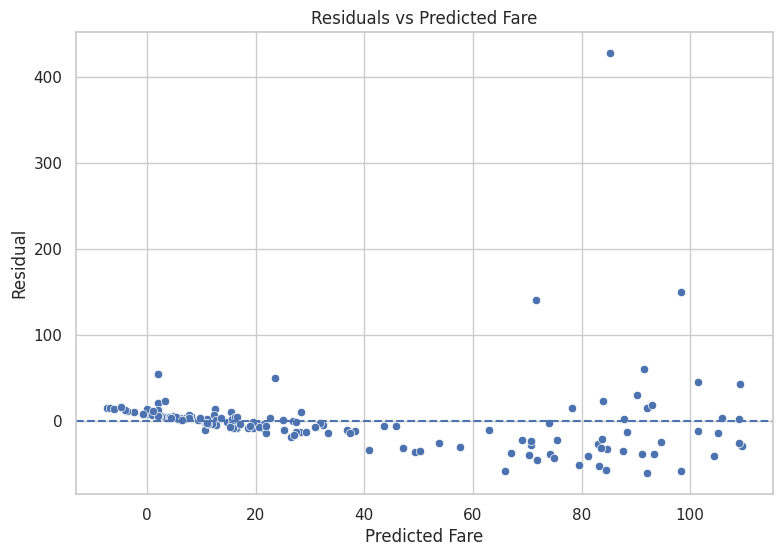

In [ ]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Fare")
plt.show()

In [ ]:
# ============================================================
# TASK 14 — FINAL MODEL COMPARISON
# ============================================================

print("CLASSIFICATION RESULTS")
display(
    results_df.sort_values(
        "ROC-AUC",
        ascending=False
    )
)

# ------------------------------------------------------------
# Regression results
# ------------------------------------------------------------

regression_results = pd.DataFrame({
    "Metric": [
        "R2",
        "Adjusted R2",
        "MAE",
        "RMSE"
    ],

    "Value": [
        r2,
        adjusted_r2,
        mae,
        rmse
    ]
})

print("\nREGRESSION RESULTS")
display(regression_results)


# ------------------------------------------------------------
# Best classifier
# ------------------------------------------------------------

best_classifier_name = (
    results_df
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

print("\nBest classifier based on ROC-AUC:")
print(best_classifier_name)

CLASSIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0



REGRESSION RESULTS


,Metric,Value
0,R2,0.360916
1,Adjusted R2,0.255804
2,MAE,18.373542
3,RMSE,41.292124



Best classifier based on ROC-AUC:
Logistic Regression


In [ ]:
# ============================================================
# TASK 15 — SAVE COMPLETE PIPELINE
# ============================================================

# ------------------------------------------------------------
# Select best classifier
# ------------------------------------------------------------

best_classifier = models[best_classifier_name]

print("Selected model:")
print(best_classifier_name)

#Final written recommendation

''' Among the classification models, the model with the strongest ROC-AUC/F1 performance should
 be preferred because the objective is to predict passenger survival. Accuracy alone should not
be used as the only selection criterion because the target classes are not perfectly balanced.
   The regression model addresses a different problem, namely predicting continuous Fare, so its R²,
    MAE and RMSE values cannot be directly compared numerically with classification accuracy, F1 or
     ROC-AUC. For the classification task, I would deploy the best-performing classifier based on the
      evaluation results and validation performance. The final selected pipeline should include preprocessing
       and the trained estimator together so that raw future data can be passed directly to the model. '''

# ------------------------------------------------------------
# Save complete pipeline
# ------------------------------------------------------------

joblib.dump(
    best_classifier,
    "best_titanic_pipeline.joblib"
)

print(
    "\nComplete pipeline saved as "
    "best_titanic_pipeline.joblib"
)


# ============================================================
# RELOAD PIPELINE
# ============================================================

loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

print("Pipeline loaded successfully.")
print(loaded_pipeline)



Selected model:
Logistic Regression

Complete pipeline saved as best_titanic_pipeline.joblib
Pipeline loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                   

In [ ]:
# ============================================================
# TEST WITH RAW NEW DATA
# ============================================================

new_passenger = pd.DataFrame({

    "pclass": [1],

    "sex": ["female"],

    "age": [30],

    "sibsp": [0],

    "parch": [0],

    "fare": [100],

    "embarked": ["S"],

    "class": ["First"],

    "who": ["woman"],

    "adult_male": [False],

    "deck": [np.nan],

    "embark_town": ["Southampton"],

    "alive": ["yes"],

    "alone": [True]

})

print("Raw new passenger:")
display(new_passenger)


# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

prediction = loaded_pipeline.predict(
    new_passenger
)

probability = loaded_pipeline.predict_proba(
    new_passenger
)[:, 1]


print("\nPrediction:")

if prediction[0] == 1:
    print("Passenger predicted to SURVIVE")
else:
    print("Passenger predicted to NOT SURVIVE")


print(
    "Survival probability:",
    round(probability[0], 4)
)

# ============================================================
# FINAL PIPELINE CHECK
# ============================================================

assert len(prediction) == 1
assert 0 <= probability[0] <= 1

print("""
============================================================
FINAL CHECK PASSED
============================================================

✓ Titanic dataset loaded
✓ Baseline titanic.csv created
✓ Same CSV reloaded
✓ Missing values handled
✓ Univariate analysis completed
✓ IQR outliers calculated
✓ Skewness calculated
✓ Bivariate analysis completed
✓ Correlation analysis completed
✓ Multivariate analysis completed
✓ Standardization check completed
✓ Stratified train/test split completed
✓ Preprocessing pipeline created
✓ Logistic Regression trained
✓ Decision Tree trained
✓ Random Forest trained
✓ Decision Tree visualized
✓ Classification metrics calculated
✓ ROC curves calculated
✓ Imbalance comparison completed
✓ SMOTE completed
✓ Class-weight balancing completed
✓ Random Forest GridSearchCV completed
✓ OOB score calculated
✓ Linear Regression completed
✓ R² calculated
✓ Adjusted R² calculated
✓ MAE calculated
✓ RMSE calculated
✓ Heteroscedasticity tested
✓ Best complete pipeline saved
✓ Pipeline reloaded
✓ Raw new-data prediction verified

Project completed successfully.
""")

Raw new passenger:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,1,female,30,0,0,100,S,First,woman,False,NaN,Southampton,yes,True



Prediction:
Passenger predicted to SURVIVE
Survival probability: 0.9954

FINAL CHECK PASSED

✓ Titanic dataset loaded
✓ Baseline titanic.csv created
✓ Same CSV reloaded
✓ Missing values handled
✓ Univariate analysis completed
✓ IQR outliers calculated
✓ Skewness calculated
✓ Bivariate analysis completed
✓ Correlation analysis completed
✓ Multivariate analysis completed
✓ Standardization check completed
✓ Stratified train/test split completed
✓ Preprocessing pipeline created
✓ Logistic Regression trained
✓ Decision Tree trained
✓ Random Forest trained
✓ Decision Tree visualized
✓ Classification metrics calculated
✓ ROC curves calculated
✓ Imbalance comparison completed
✓ SMOTE completed
✓ Class-weight balancing completed
✓ Random Forest GridSearchCV completed
✓ OOB score calculated
✓ Linear Regression completed
✓ R² calculated
✓ Adjusted R² calculated
✓ MAE calculated
✓ RMSE calculated
✓ Heteroscedasticity tested
✓ Best complete pipeline saved
✓ Pipeline reloaded
✓ Raw new-data predict